In [3]:
# ==============================================
# Comprension_eda.ipynb - Avance #1 (V1.0.1)
# ==============================================

## 0. Imports y configuración global
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración visual y display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías cargadas y configuración aplicada")

Librerías cargadas y configuración aplicada


In [4]:
## 1. Carga del dataset
df = pd.read_csv('../Base_de_datos.csv', encoding='utf-8')

print("Forma inicial:", df.shape)
display(df.head(5))
df.info()

Forma inicial: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,12/21/24 11:31,3692160,10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,51258.00,51258.00,0.00,5,0,0,908526.00,Estable,1
1,4,4/22/25 9:47,840000,6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,8673.00,8673.00,0.00,0,0,2,939017.00,Creciente,1
2,9,1/8/26 12:22,5974028,10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,18702.00,18702.00,0.00,3,0,0,NaN,NaN,0
3,4,8/4/25 12:04,1671240,6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,15782.00,15782.00,0.00,3,0,0,1536193.00,Creciente,1
4,9,4/26/25 11:24,2781636,11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,204804.00,204804.00,0.00,3,0,1,933473.00,Creciente,1


<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   tipo_credito                   10763 non-null  int64  
 1   fecha_prestamo                 10763 non-null  str    
 2   capital_prestado               10763 non-null  int64  
 3   plazo_meses                    10763 non-null  int64  
 4   edad_cliente                   10763 non-null  int64  
 5   tipo_laboral                   10763 non-null  str    
 6   salario_cliente                10763 non-null  int64  
 7   total_otros_prestamos          10763 non-null  int64  
 8   cuota_pactada                  10763 non-null  int64  
 9   puntaje                        10763 non-null  float64
 10  puntaje_datacredito            10757 non-null  float64
 11  cant_creditosvigentes          10763 non-null  int64  
 12  huella_consulta                10763 non-null  int64  
 1

In [3]:
## 2. Clasificación de variables (actualizada)
numericas = [
    'capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
    'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito',
    'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total',
    'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero',
    'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito'
]

ordinales = ['tipo_credito']  # ordinal por niveles
nominales = ['tipo_laboral']  # sin orden
fechas = ['fecha_prestamo']
objetivo = 'Pago_atiempo'

print("Clasificación de variables:")
print("Numéricas:", numericas)
print("Ordinales:", ordinales)
print("Nominales:", nominales)
print("Fechas:", fechas)
print("Objetivo:", objetivo)

Clasificación de variables:
Numéricas: ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']
Ordinales: ['tipo_credito']
Nominales: ['tipo_laboral']
Fechas: ['fecha_prestamo']
Objetivo: Pago_atiempo


In [4]:
## 3. Tratamiento de nulos - Imputación numéricas con mediana
print("Imputación numéricas con mediana:")

for col in numericas:
    if col in df.columns and df[col].isnull().any():
        mediana = df[col].median()
        nulos_antes = df[col].isnull().sum()
        df[col] = df[col].fillna(mediana)
        print(f"{col}: {nulos_antes} nulos → imputados con mediana = {mediana}")

print("\nNulos restantes en numéricas:", df[numericas].isnull().sum().sum())

Imputación numéricas con mediana:
puntaje_datacredito: 6 nulos → imputados con mediana = 791.0
saldo_mora: 156 nulos → imputados con mediana = 0.0
saldo_total: 156 nulos → imputados con mediana = 16178.0
saldo_principal: 405 nulos → imputados con mediana = 14442.5
saldo_mora_codeudor: 590 nulos → imputados con mediana = 0.0
promedio_ingresos_datacredito: 2930 nulos → imputados con mediana = 1204496.0

Nulos restantes en numéricas: 0


Distribución ORIGINAL de tendencia_ingresos:
tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
158042            1
3978              1
168750            1
-28589            1
-566272           1
24702             1
31837             1
Name: count, dtype: int64

==== DATA QUALITY REPORT ====
NaN reales: 2990
Corrupción detectada: 0

Distribución FINAL de tendencia_ingresos:
tendencia_ingresos
Creciente      5294
Sin_dato       2990
Decreciente    1291
Estable        1188
Error_dato        0
Name: count, dtype: int64


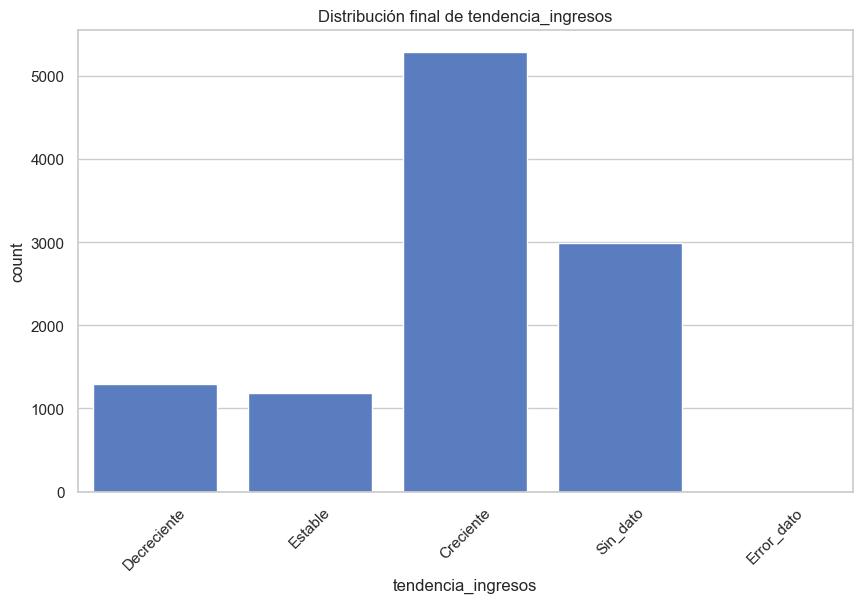


Interpretación:
- Valores corruptos (números y basura) se marcaron como 'Error_dato'.
- Nulos originales se marcaron como 'Sin_dato'.
- La columna ahora es ordinal tipada, lista para análisis y modelado.
- 'Sin_dato' y 'Error_dato' son categorías informativas que pueden correlacionar con riesgo.



In [5]:
## 4. Limpieza avanzada y tratamiento de tendencia_ingresos (tu código mejorado)
col = "tendencia_ingresos"

print(f"Distribución ORIGINAL de {col}:")
print(df[col].value_counts(dropna=False).head(15))

# 1. Normalización de strings
df[col] = (
    df[col]
    .astype("string")
    .str.strip()
    .str.lower()
)

# 2. Mapeo de valores válidos
mapping = {
    "creciente": "Creciente",
    "estable": "Estable",
    "decreciente": "Decreciente"
}
df[col] = df[col].map(mapping)

# 3. Separar tipos de problema
mask_nan_original = df[col].isna()
mask_corrupto = ~df[col].isin(mapping.values()) & ~mask_nan_original

# 4. Imputaciones diferenciadas
df.loc[mask_corrupto, col] = "Error_dato"
df[col] = df[col].fillna("Sin_dato")

# 5. Convertir a categórica ordenada
df[col] = pd.Categorical(
    df[col],
    categories=["Decreciente", "Estable", "Creciente", "Sin_dato", "Error_dato"],
    ordered=True
)

# 6. Reporte de calidad
print("\n==== DATA QUALITY REPORT ====")
print("NaN reales:", mask_nan_original.sum())
print("Corrupción detectada:", mask_corrupto.sum())
print("\nDistribución FINAL de tendencia_ingresos:")
print(df[col].value_counts(dropna=False))

# Gráfico
plt.figure(figsize=(10, 6))
sns.countplot(x=df[col], order=df[col].cat.categories)
plt.title('Distribución final de tendencia_ingresos')
plt.xticks(rotation=45)
plt.show()

print("""
Interpretación:
- Valores corruptos (números y basura) se marcaron como 'Error_dato'.
- Nulos originales se marcaron como 'Sin_dato'.
- La columna ahora es ordinal tipada, lista para análisis y modelado.
- 'Sin_dato' y 'Error_dato' son categorías informativas que pueden correlacionar con riesgo.
""")

In [6]:
## 5. Verificación final de nulos en todo el dataset
print("Nulos restantes después de todo el tratamiento:")
nulos_final = df.isnull().sum()
print(nulos_final[nulos_final > 0])

if nulos_final.sum() == 0:
    print("\n¡Dataset completamente sin nulos!")
else:
    print("\nQuedan algunos nulos menores (revisar si son aceptables).")

Nulos restantes después de todo el tratamiento:
Series([], dtype: int64)

¡Dataset completamente sin nulos!


=== ANÁLISIS UNIVARIABLE - Numéricas ===

--- capital_prestado ---
count      10763.00
mean     2434315.00
std      1909642.76
min       360000.00
25%      1224831.00
50%      1921920.00
75%      3084840.00
max     41444153.00
Name: capital_prestado, dtype: float64
Skewness: 3.72 | Kurtosis: 35.32
Sesgo positivo → posible transformación logarítmica


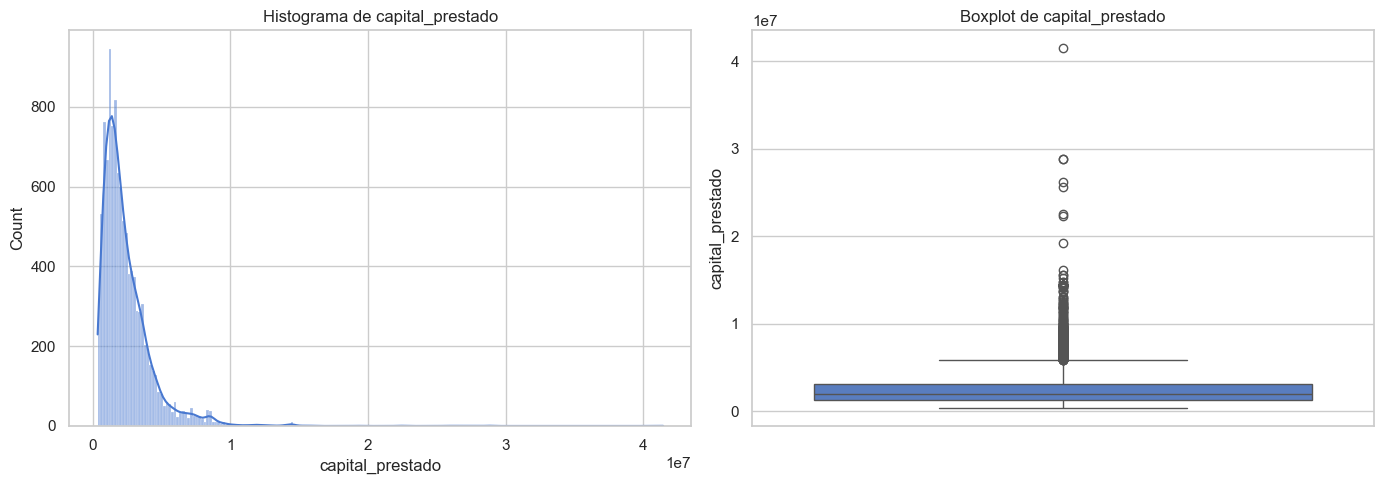

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- plazo_meses ---
count   10763.00
mean       10.58
std         6.63
min         2.00
25%         6.00
50%        10.00
75%        12.00
max        90.00
Name: plazo_meses, dtype: float64
Skewness: 2.46 | Kurtosis: 7.78
Sesgo positivo → posible transformación logarítmica


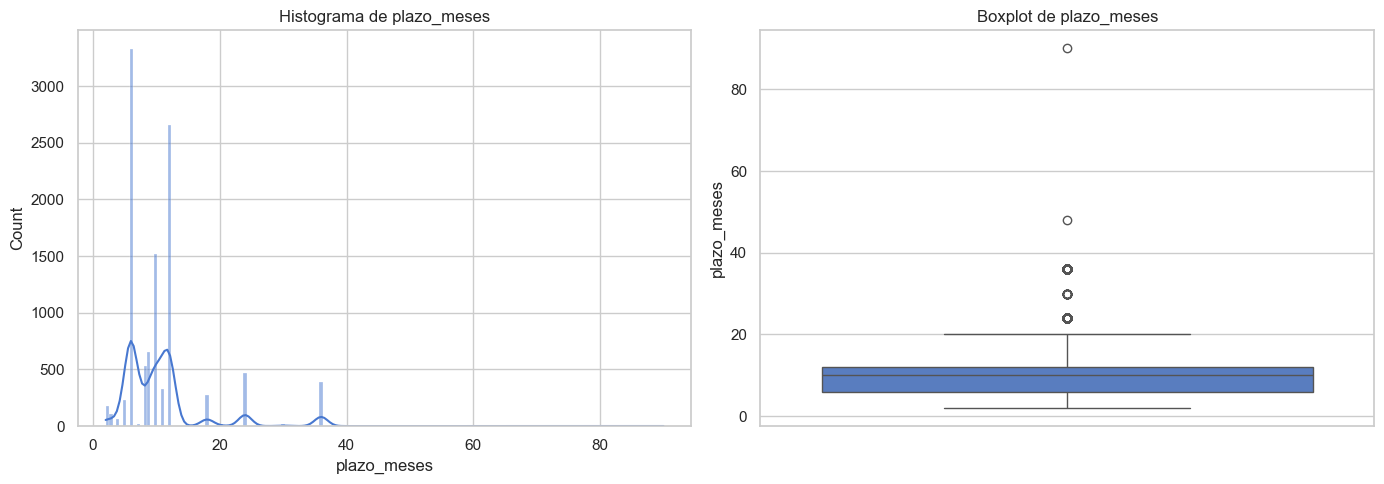

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- edad_cliente ---
count   10763.00
mean       43.95
std        15.06
min        19.00
25%        33.00
50%        42.00
75%        53.00
max       123.00
Name: edad_cliente, dtype: float64
Skewness: 1.93 | Kurtosis: 7.87
Sesgo positivo → posible transformación logarítmica


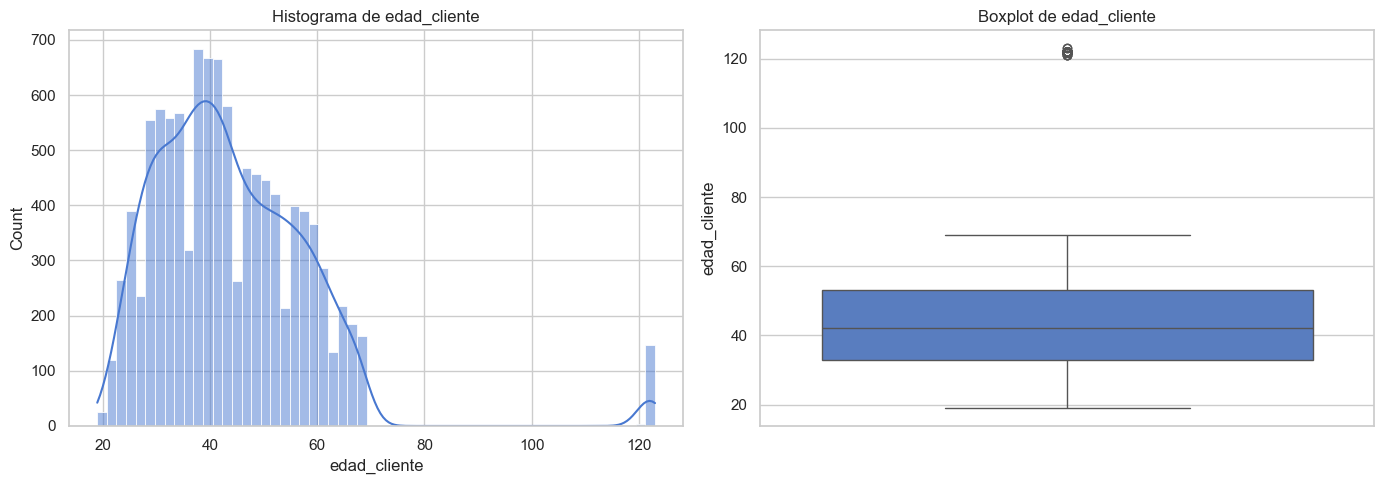

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- salario_cliente ---
count         10763.00
mean       17216431.46
std       355476717.60
min               0.00
25%         2000000.00
50%         3000000.00
75%         4875808.00
max     22000000000.00
Name: salario_cliente, dtype: float64
Skewness: 43.78 | Kurtosis: 2211.23
Sesgo positivo → posible transformación logarítmica


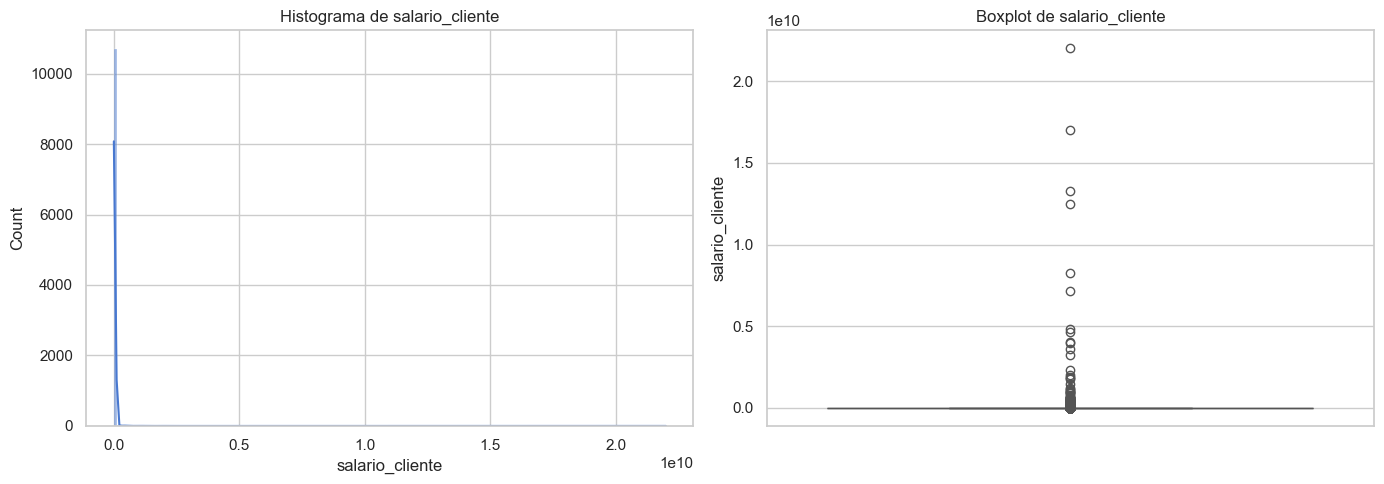

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- total_otros_prestamos ---
count        10763.00
mean       6238869.65
std      118418316.94
min              0.00
25%         500000.00
50%        1000000.00
75%        2000000.00
max     6787675263.00
Name: total_otros_prestamos, dtype: float64
Skewness: 38.46 | Kurtosis: 1719.28
Sesgo positivo → posible transformación logarítmica


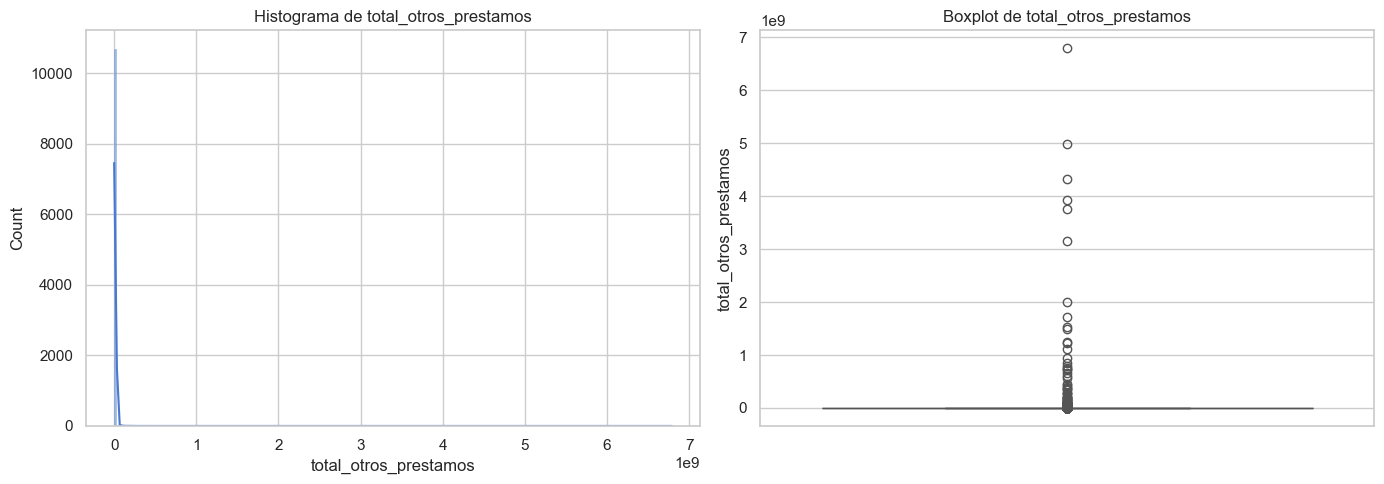

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- cuota_pactada ---
count     10763.00
mean     243617.41
std      210493.69
min       23944.00
25%      121041.50
50%      182863.00
75%      287833.50
max     3816752.00
Name: cuota_pactada, dtype: float64
Skewness: 3.79 | Kurtosis: 26.65
Sesgo positivo → posible transformación logarítmica


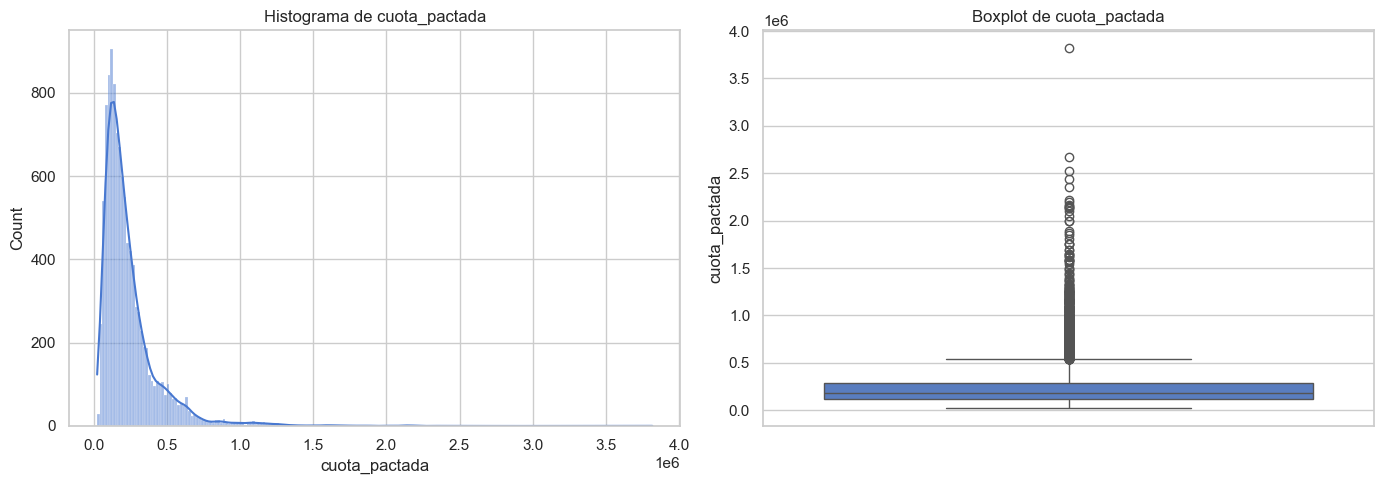

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- puntaje ---
count   10763.00
mean       91.17
std        16.47
min       -38.01
25%        95.23
50%        95.23
75%        95.23
max        95.23
Name: puntaje, dtype: float64
Skewness: -4.87 | Kurtosis: 24.08


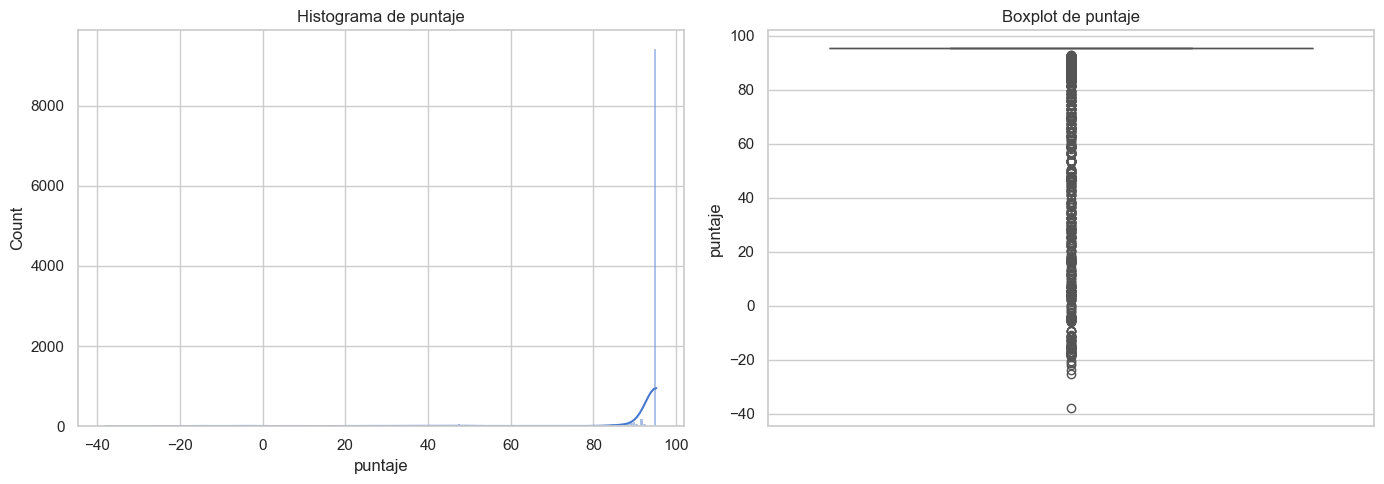

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- puntaje_datacredito ---
count   10763.00
mean      780.80
std       104.85
min        -7.00
25%       757.00
50%       791.00
75%       825.00
max       999.00
Name: puntaje_datacredito, dtype: float64
Skewness: -5.65 | Kurtosis: 39.46


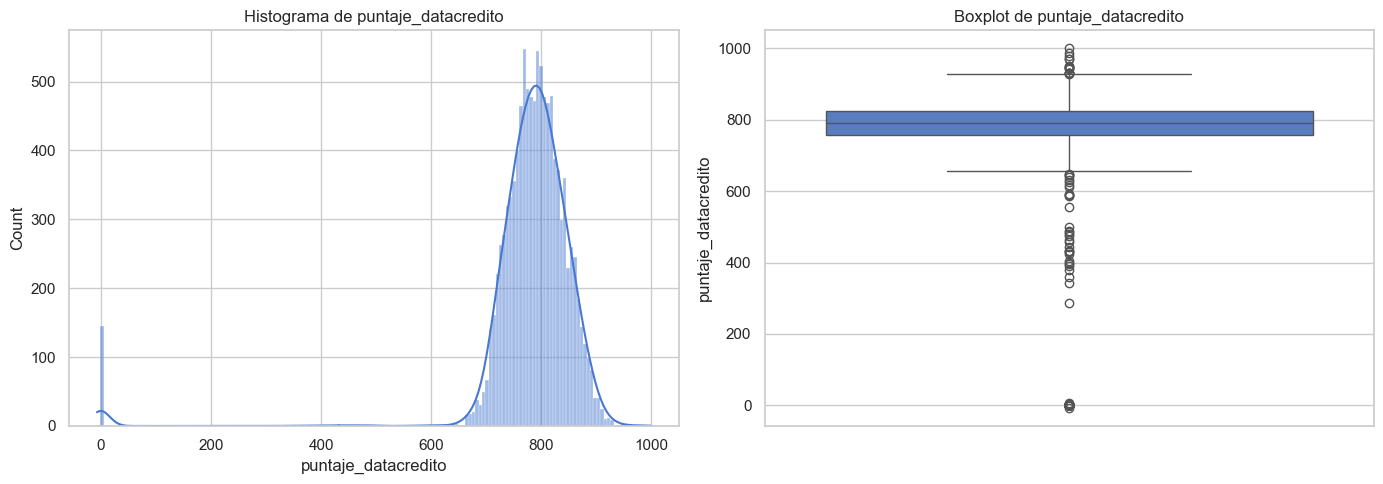

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- cant_creditosvigentes ---
count   10763.00
mean        5.73
std         3.98
min         0.00
25%         3.00
50%         5.00
75%         8.00
max        62.00
Name: cant_creditosvigentes, dtype: float64
Skewness: 1.80 | Kurtosis: 8.62
Sesgo positivo → posible transformación logarítmica


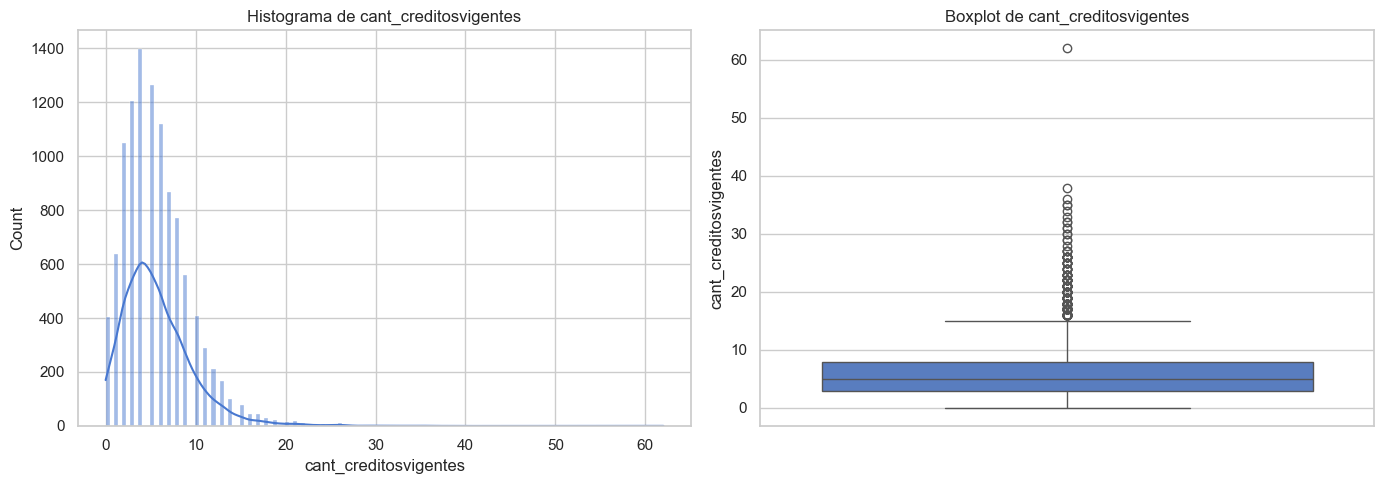

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- huella_consulta ---
count   10763.00
mean        4.23
std         3.06
min         0.00
25%         2.00
50%         4.00
75%         6.00
max        29.00
Name: huella_consulta, dtype: float64
Skewness: 1.49 | Kurtosis: 4.00
Sesgo positivo → posible transformación logarítmica


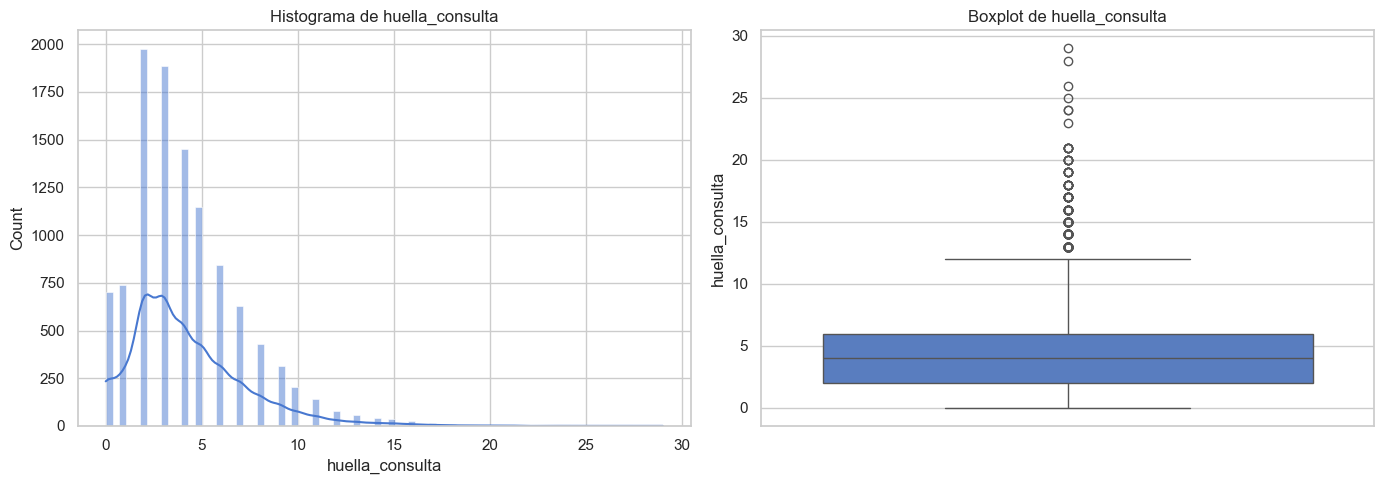

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- saldo_mora ---
count   10763.00
mean        7.63
std       224.31
min         0.00
25%         0.00
50%         0.00
75%         0.00
max     12534.00
Name: saldo_mora, dtype: float64
Skewness: 40.87 | Kurtosis: 1872.91
Sesgo positivo → posible transformación logarítmica


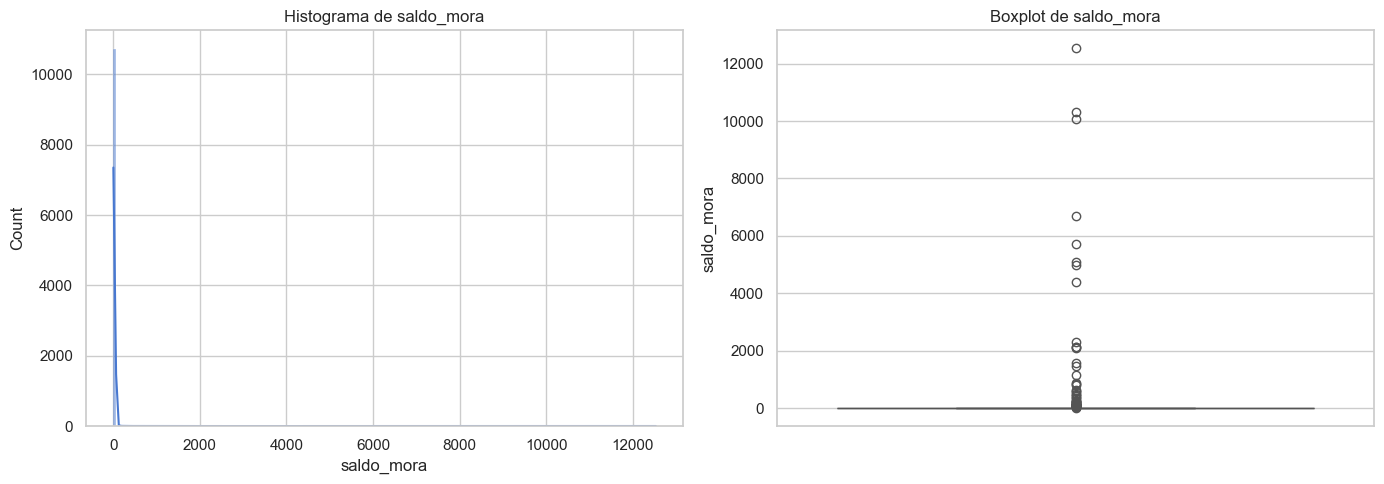

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- saldo_total ---
count     10763.00
mean      45506.07
std      105556.71
min           0.00
25%        3025.00
50%       16178.00
75%       52156.00
max     5116066.00
Name: saldo_total, dtype: float64
Skewness: 20.32 | Kurtosis: 799.32
Sesgo positivo → posible transformación logarítmica


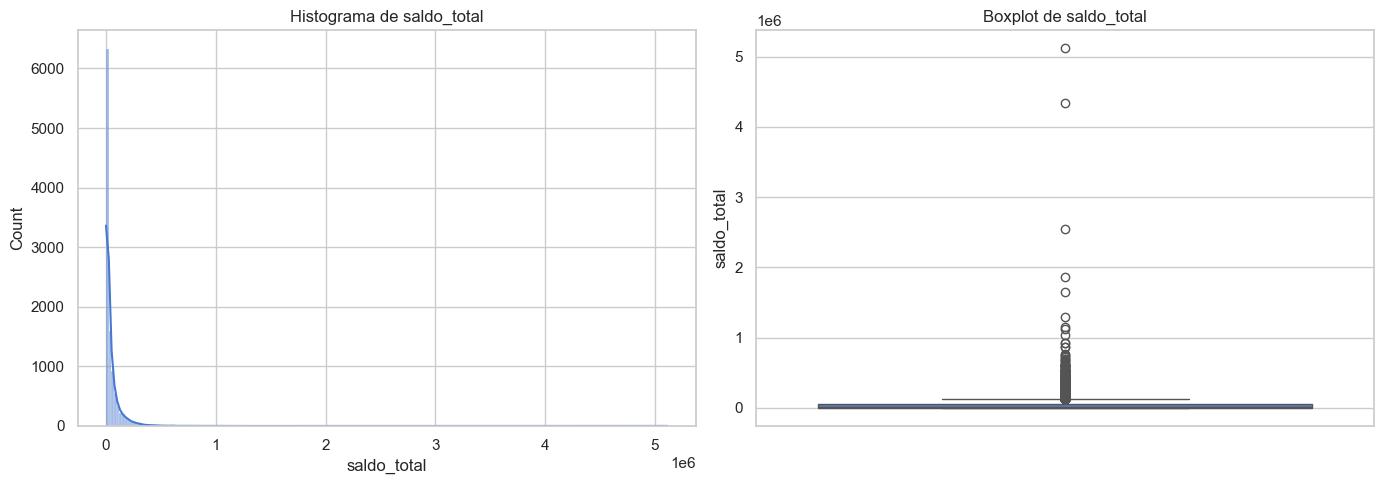

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- saldo_principal ---
count     10763.00
mean      39371.44
std       70062.71
min           0.00
25%        2999.00
50%       14442.50
75%       45297.00
max     1562285.00
Name: saldo_principal, dtype: float64
Skewness: 5.15 | Kurtosis: 52.91
Sesgo positivo → posible transformación logarítmica


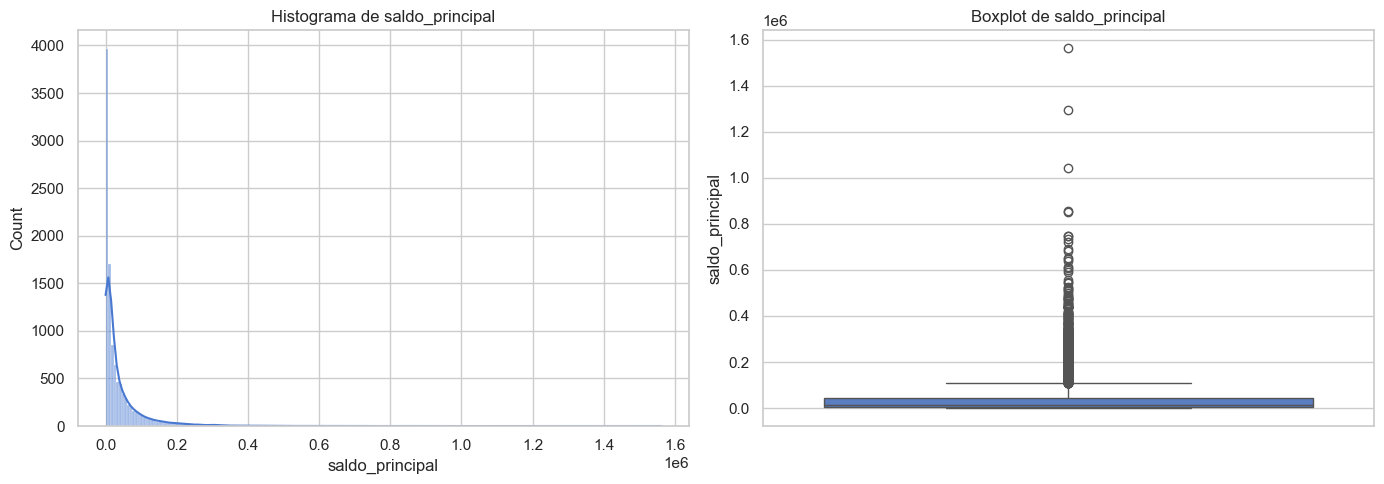

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- saldo_mora_codeudor ---
count   10763.00
mean        0.25
std        21.17
min         0.00
25%         0.00
50%         0.00
75%         0.00
max      2145.00
Name: saldo_mora_codeudor, dtype: float64
Skewness: 97.69 | Kurtosis: 9818.04
Sesgo positivo → posible transformación logarítmica


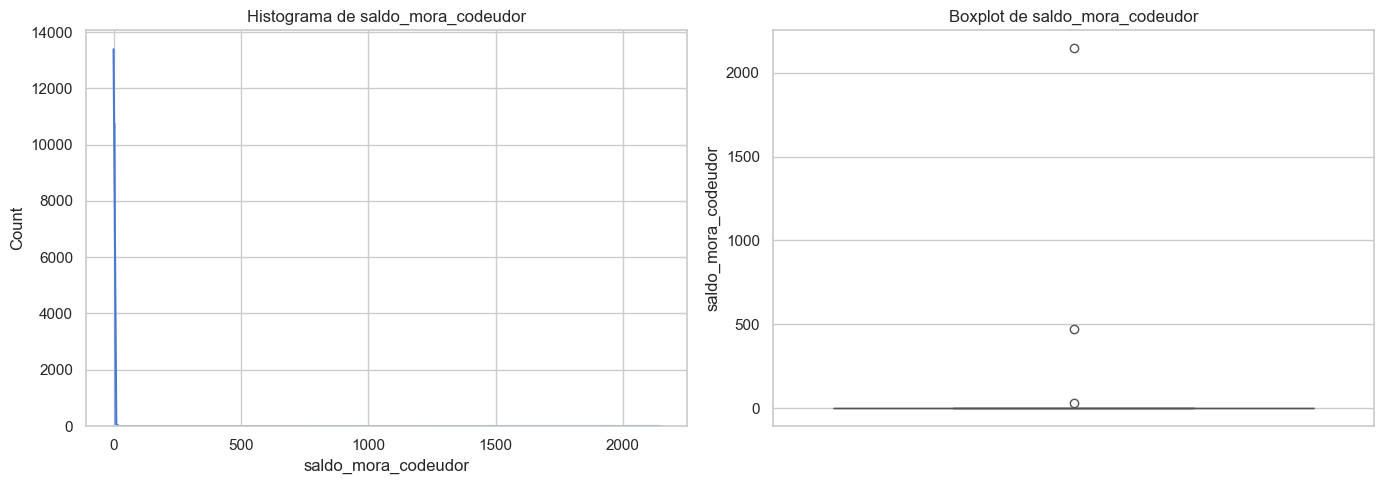

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- creditos_sectorFinanciero ---
count   10763.00
mean        2.78
std         2.75
min         0.00
25%         1.00
50%         2.00
75%         4.00
max        51.00
Name: creditos_sectorFinanciero, dtype: float64
Skewness: 2.70 | Kurtosis: 19.44
Sesgo positivo → posible transformación logarítmica


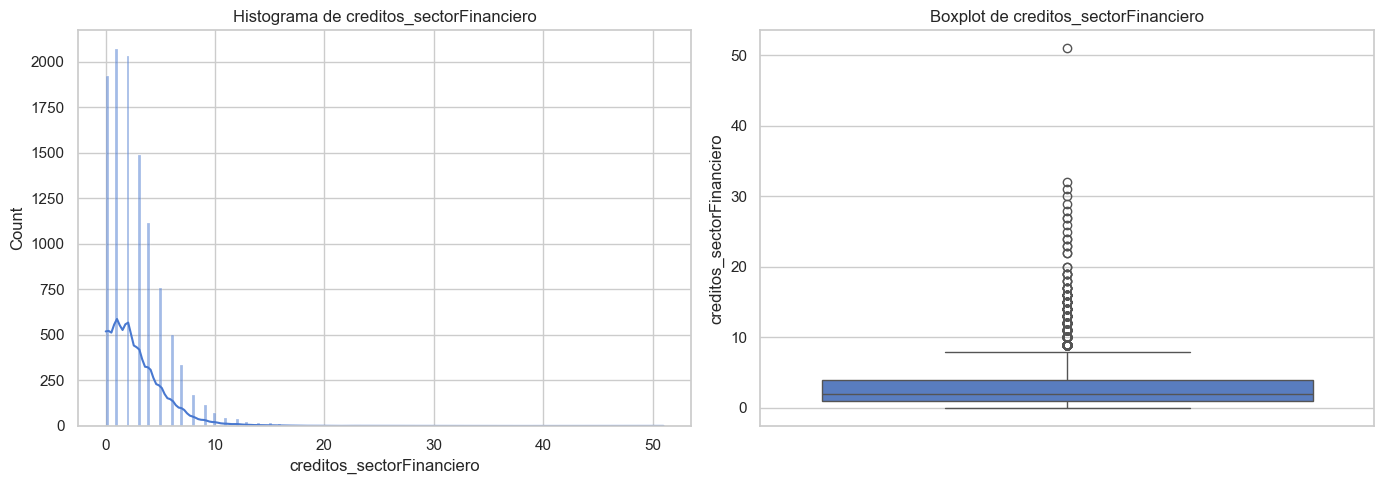

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- creditos_sectorCooperativo ---
count   10763.00
mean        0.27
std         0.72
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        13.00
Name: creditos_sectorCooperativo, dtype: float64
Skewness: 4.22 | Kurtosis: 29.35
Sesgo positivo → posible transformación logarítmica


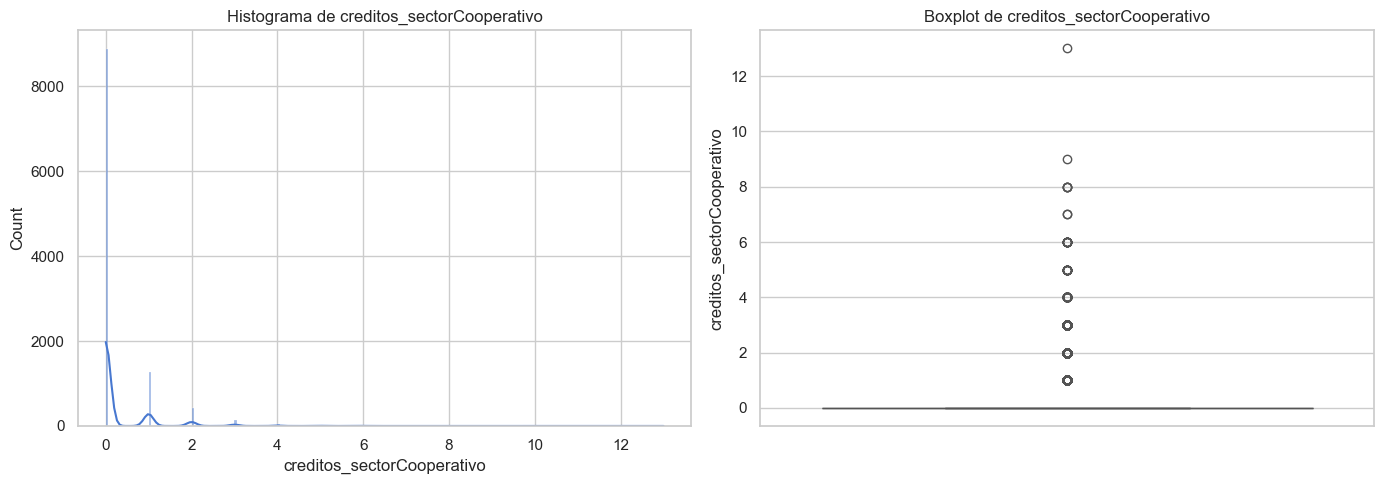

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- creditos_sectorReal ---
count   10763.00
mean        1.30
std         1.82
min         0.00
25%         0.00
50%         1.00
75%         2.00
max        25.00
Name: creditos_sectorReal, dtype: float64
Skewness: 3.16 | Kurtosis: 18.19
Sesgo positivo → posible transformación logarítmica


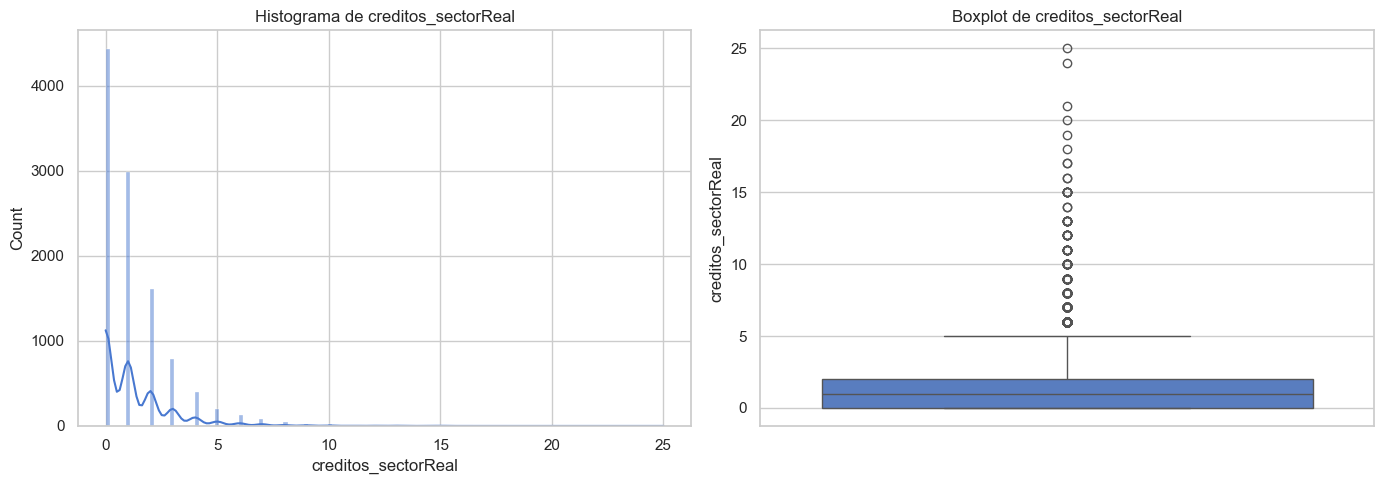

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.

--- promedio_ingresos_datacredito ---
count      10763.00
mean     1787193.77
std      1863501.02
min            0.00
25%       961885.00
50%      1204496.00
75%      1705770.00
max     38106581.00
Name: promedio_ingresos_datacredito, dtype: float64
Skewness: 5.08 | Kurtosis: 44.92
Sesgo positivo → posible transformación logarítmica


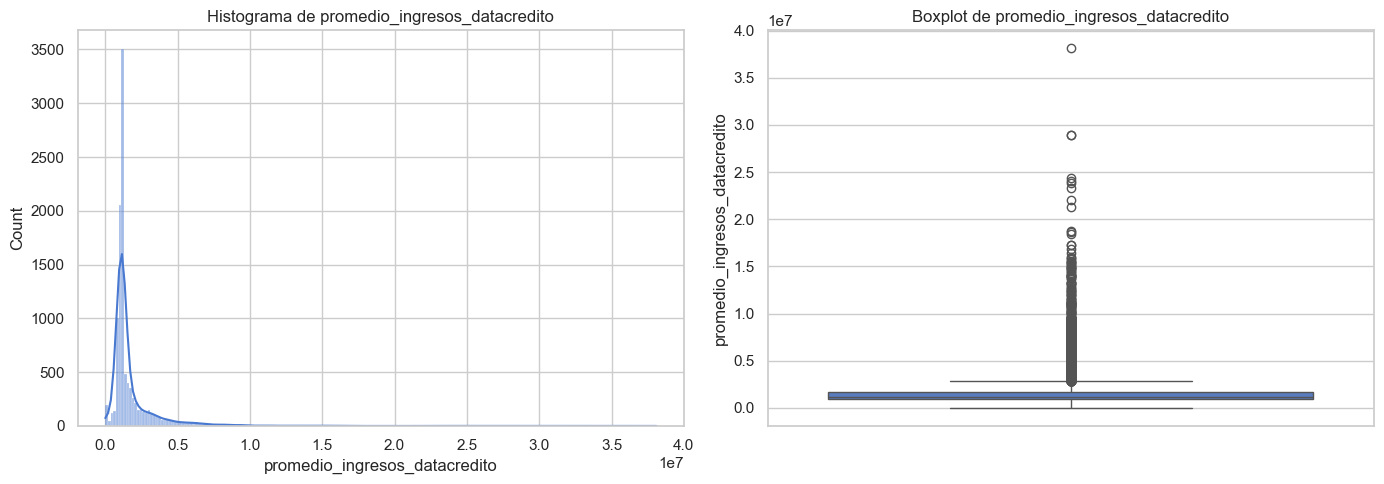

Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.


In [7]:
## 6. Análisis univariable - Numéricas (describe + gráficos + estadísticas)
print("=== ANÁLISIS UNIVARIABLE - Numéricas ===")

for col in numericas:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].describe().round(2))
        
        skew = df[col].skew()
        kurt = df[col].kurt()
        print(f"Skewness: {skew:.2f} | Kurtosis: {kurt:.2f}")
        if abs(skew) < 0.5:
            print("Distribución ≈ normal")
        elif skew > 0.5:
            print("Sesgo positivo → posible transformación logarítmica")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.histplot(df[col], kde=True, ax=axes[0])
        axes[0].set_title(f'Histograma de {col}')
        sns.boxplot(y=df[col], ax=axes[1])
        axes[1].set_title(f'Boxplot de {col}')
        plt.tight_layout()
        plt.show()
        
        print("Interpretación: [ejemplo] Alta concentración en valores bajos, outliers altos en capital_prestado.")

=== ANÁLISIS UNIVARIABLE - Categóricas / Ordinales ===

--- tipo_credito ---
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

Porcentajes:
tipo_credito
4    72.00
9    26.70
10    1.10
6     0.20
7     0.00
68    0.00
Name: proportion, dtype: float64


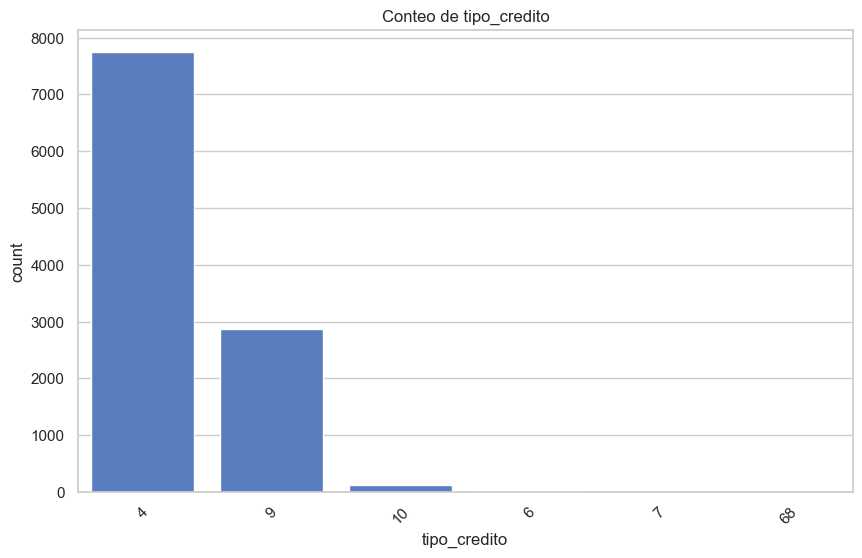

Interpretación: [ejemplo] Mayoría 'Creciente' en tendencia_ingresos, desbalance en Pago_atiempo.

--- tipo_laboral ---
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

Porcentajes:
tipo_laboral
Empleado        62.80
Independiente   37.20
Name: proportion, dtype: float64


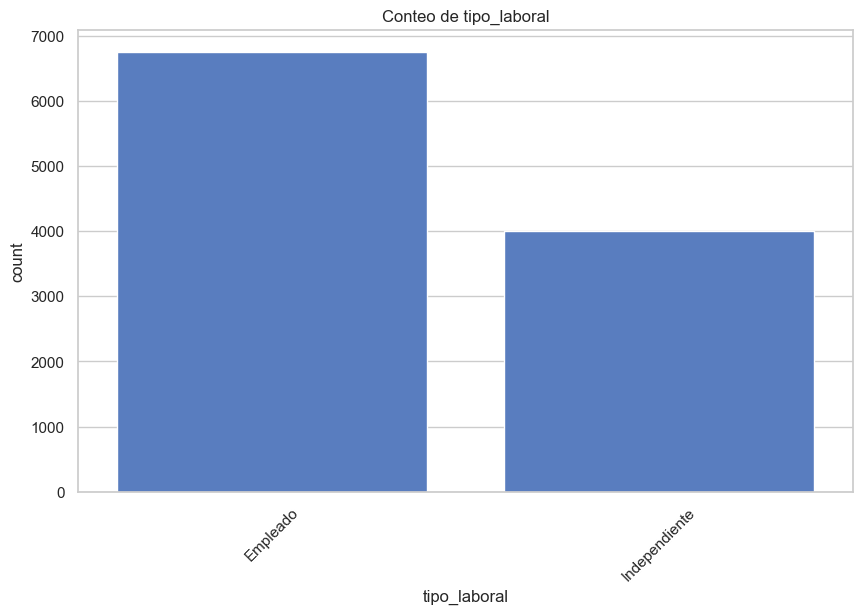

Interpretación: [ejemplo] Mayoría 'Creciente' en tendencia_ingresos, desbalance en Pago_atiempo.

--- Pago_atiempo ---
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

Porcentajes:
Pago_atiempo
1   95.30
0    4.70
Name: proportion, dtype: float64


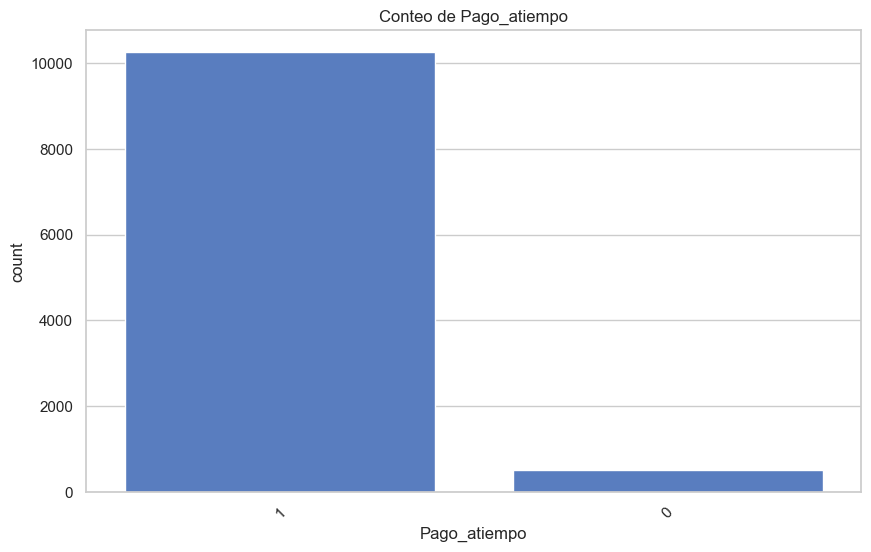

Interpretación: [ejemplo] Mayoría 'Creciente' en tendencia_ingresos, desbalance en Pago_atiempo.


In [8]:
## 7. Análisis univariable - Categóricas / Ordinales / Objetivo
print("=== ANÁLISIS UNIVARIABLE - Categóricas / Ordinales ===")

for col in ordinales + nominales + [objetivo]:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False))
        print("\nPorcentajes:")
        print(df[col].value_counts(normalize=True, dropna=False).round(3) * 100)
        
        plt.figure(figsize=(10, 6))
        sns.countplot(x=df[col], order=df[col].value_counts().index)
        plt.title(f'Conteo de {col}')
        plt.xticks(rotation=45)
        plt.show()
        
        print("Interpretación: [ejemplo] Mayoría 'Creciente' en tendencia_ingresos, desbalance en Pago_atiempo.")

=== ANÁLISIS BIVARIABLE ===


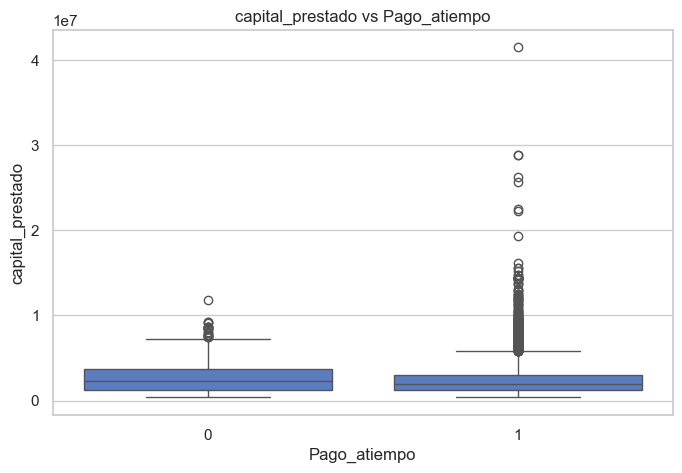

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


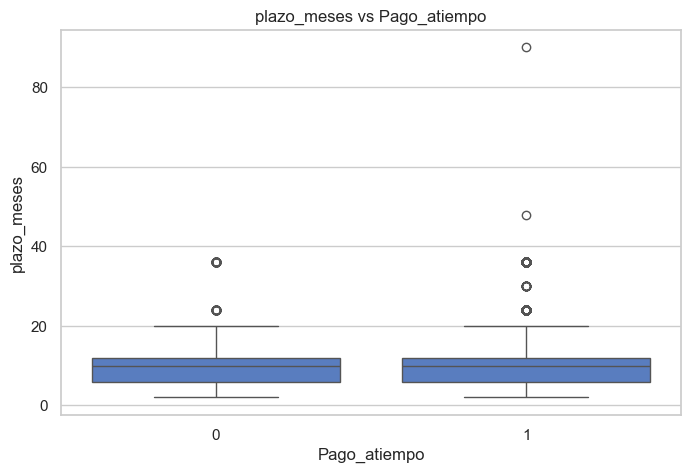

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


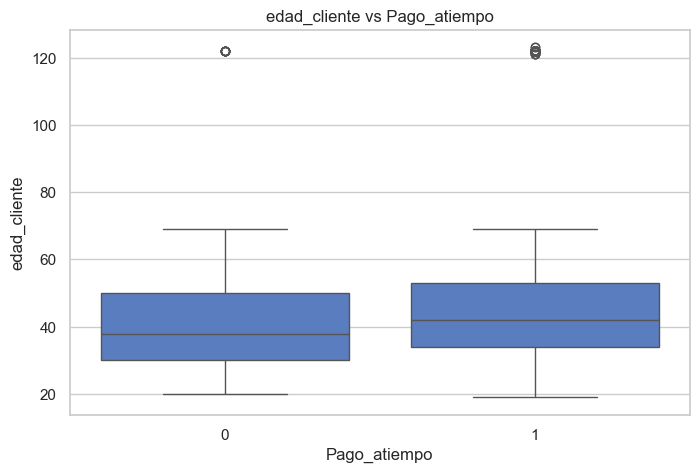

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


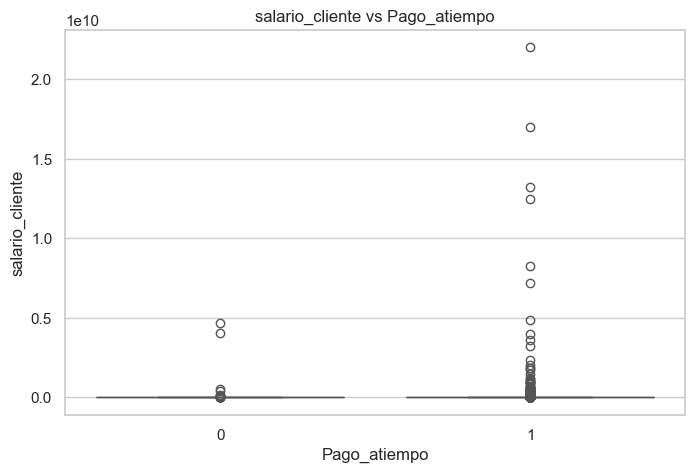

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


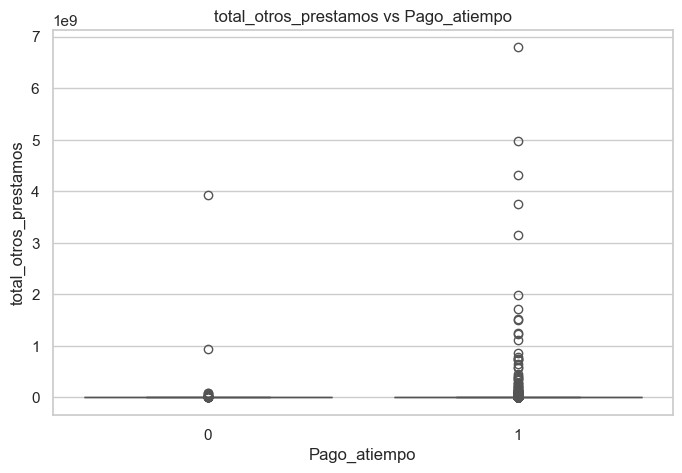

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


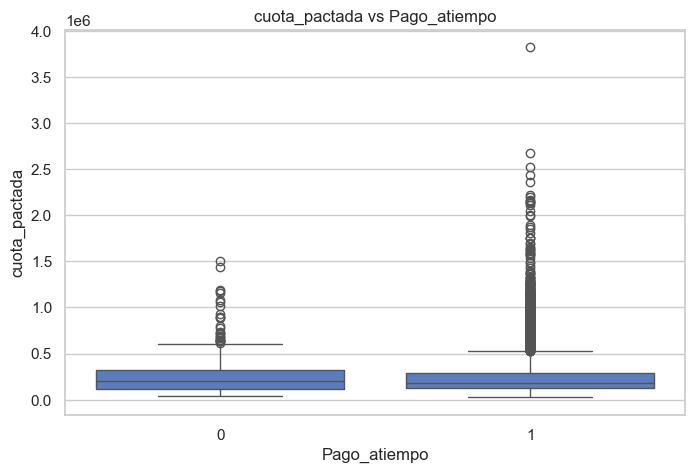

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


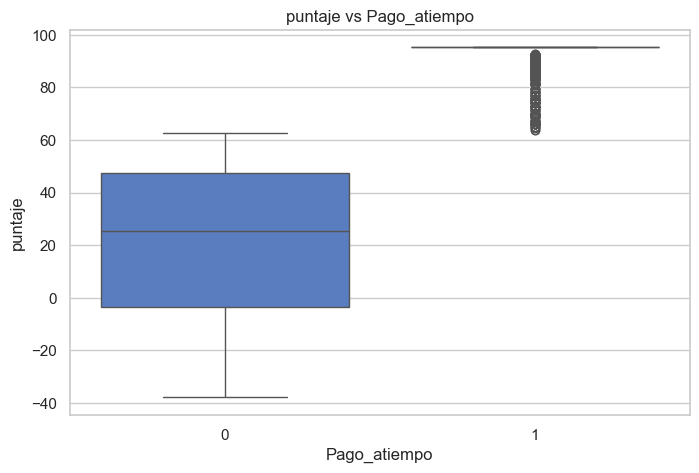

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


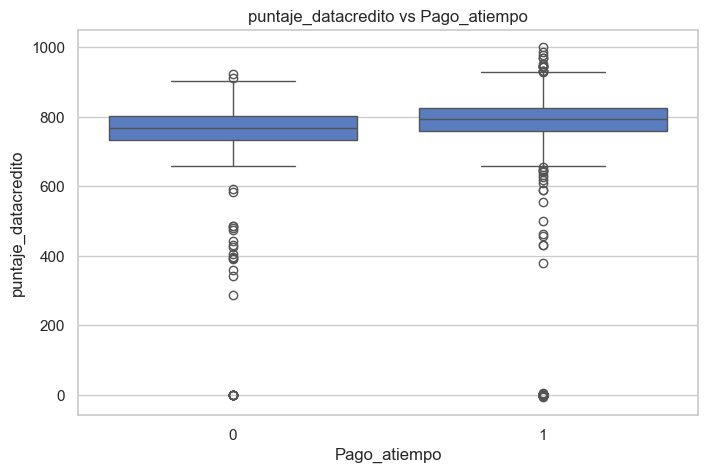

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


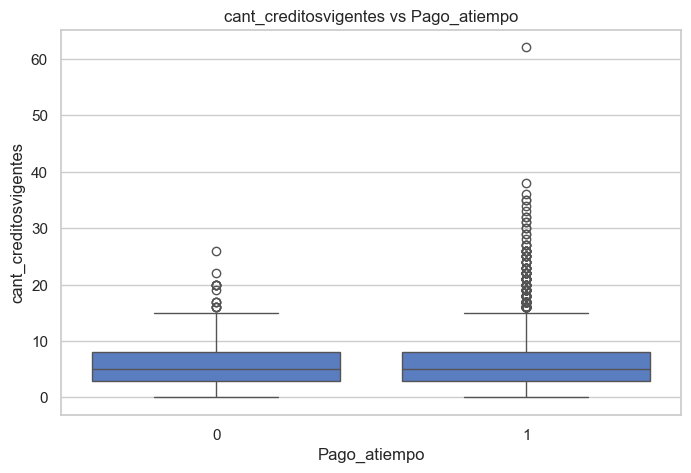

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


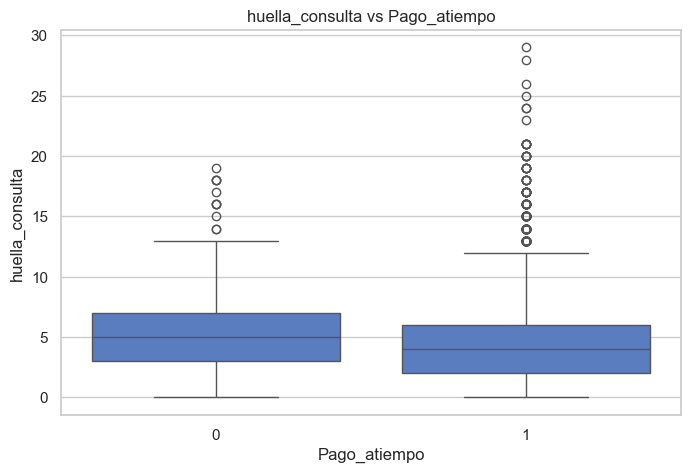

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


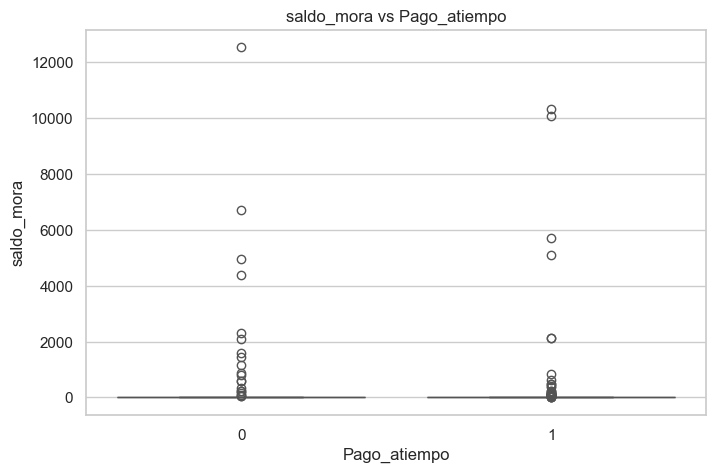

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


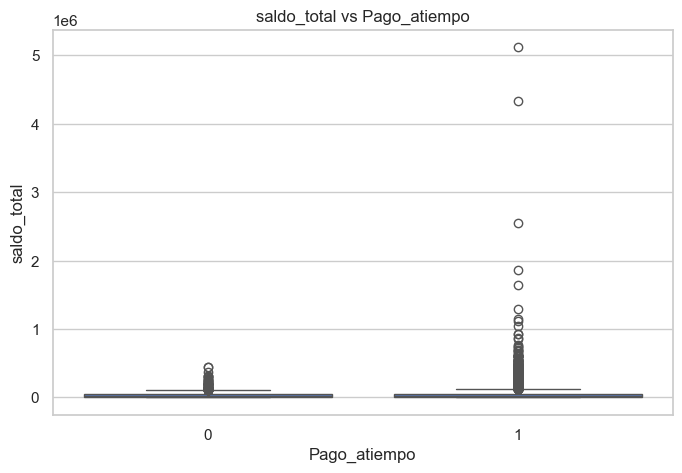

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


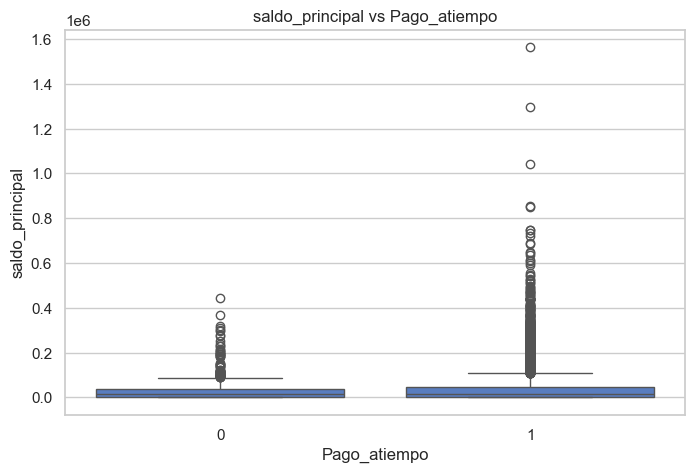

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


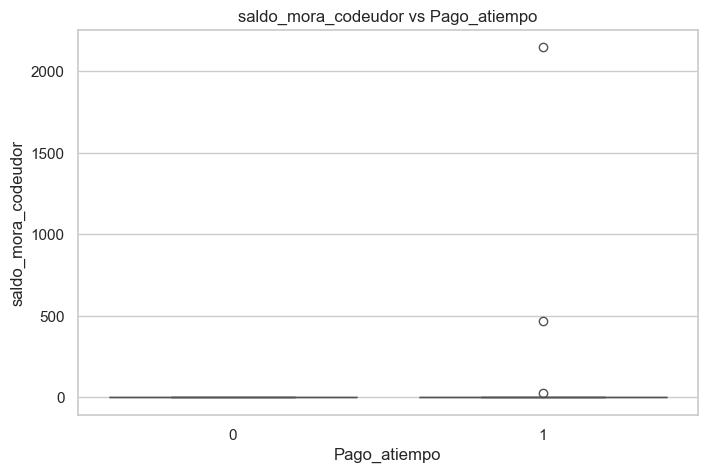

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


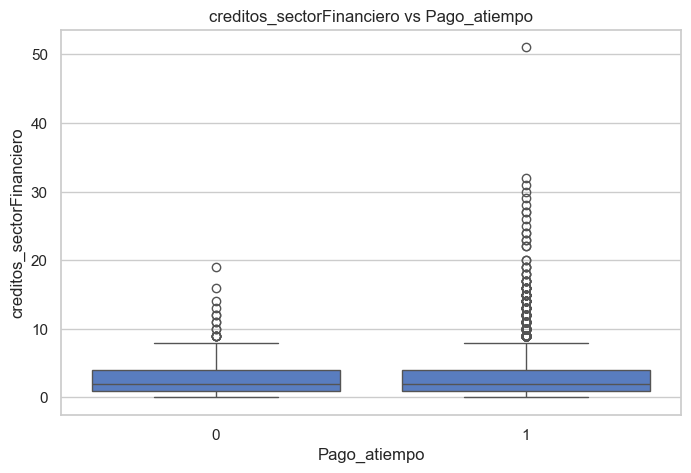

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


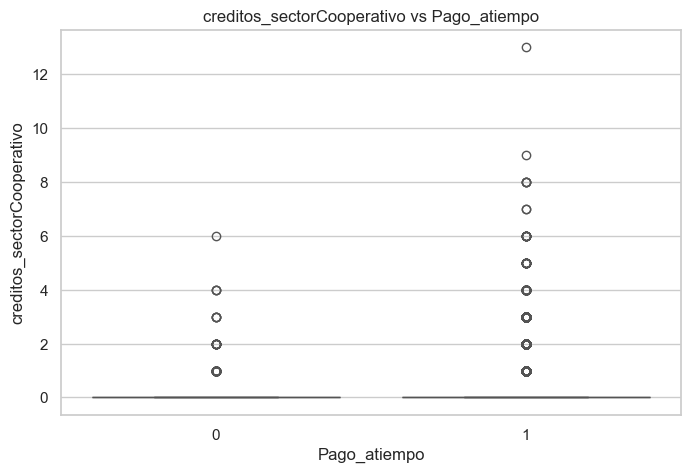

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


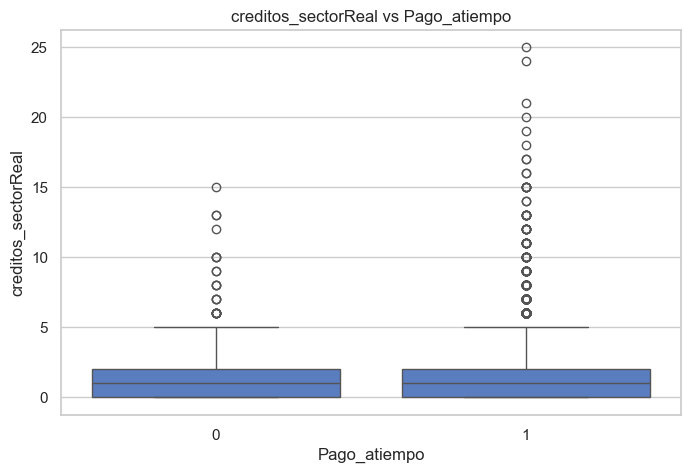

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.


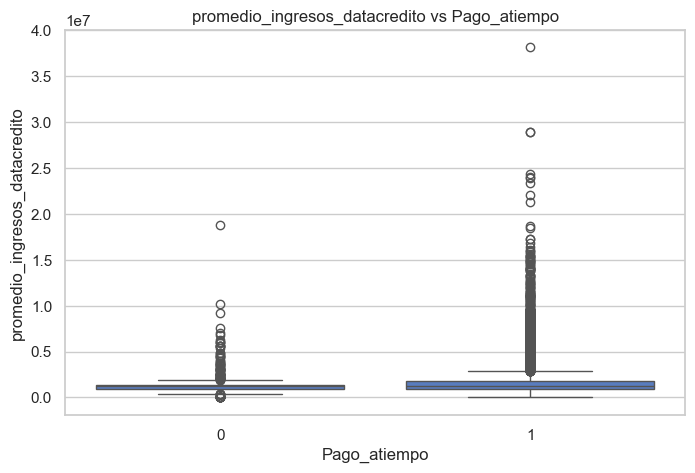

Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.

Crosstab tipo_credito vs Pago_atiempo:
Pago_atiempo     0      1
tipo_credito             
4             4.70  95.30
6            42.90  57.10
7             0.00 100.00
9             4.70  95.30
10            2.60  97.40
68            0.00 100.00


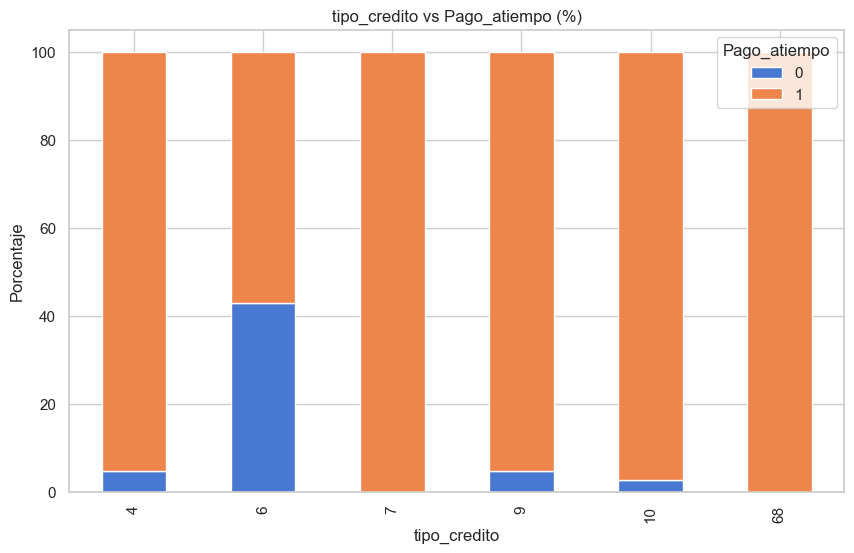

Interpretación: [ejemplo] Clientes con tendencia 'Creciente' tienen mayor % de pago a tiempo.

Crosstab tipo_laboral vs Pago_atiempo:
Pago_atiempo     0     1
tipo_laboral            
Empleado      4.30 95.70
Independiente 5.50 94.50


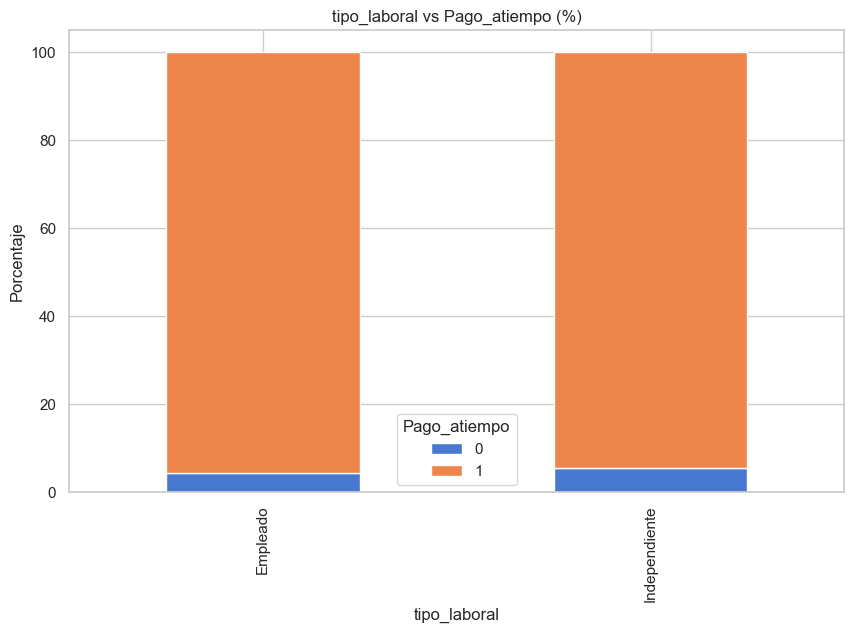

Interpretación: [ejemplo] Clientes con tendencia 'Creciente' tienen mayor % de pago a tiempo.


In [9]:
## 8. Análisis Bivariable (vs Pago_atiempo)
print("=== ANÁLISIS BIVARIABLE ===")

for col in numericas:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(x='Pago_atiempo', y=col, data=df)
        plt.title(f'{col} vs Pago_atiempo')
        plt.show()
        print(f"Interpretación: [ejemplo] Clientes que pagan a tiempo tienen mediana de puntaje más alta.")

for col in ordinales + nominales:
    if col in df.columns:
        crosstab = pd.crosstab(df[col], df['Pago_atiempo'], normalize='index').round(3) * 100
        print(f"\nCrosstab {col} vs Pago_atiempo:")
        print(crosstab)
        
        crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
        plt.title(f'{col} vs Pago_atiempo (%)')
        plt.ylabel('Porcentaje')
        plt.show()
        
        print("Interpretación: [ejemplo] Clientes con tendencia 'Creciente' tienen mayor % de pago a tiempo.")

=== ANÁLISIS MULTIVARIABLE ===


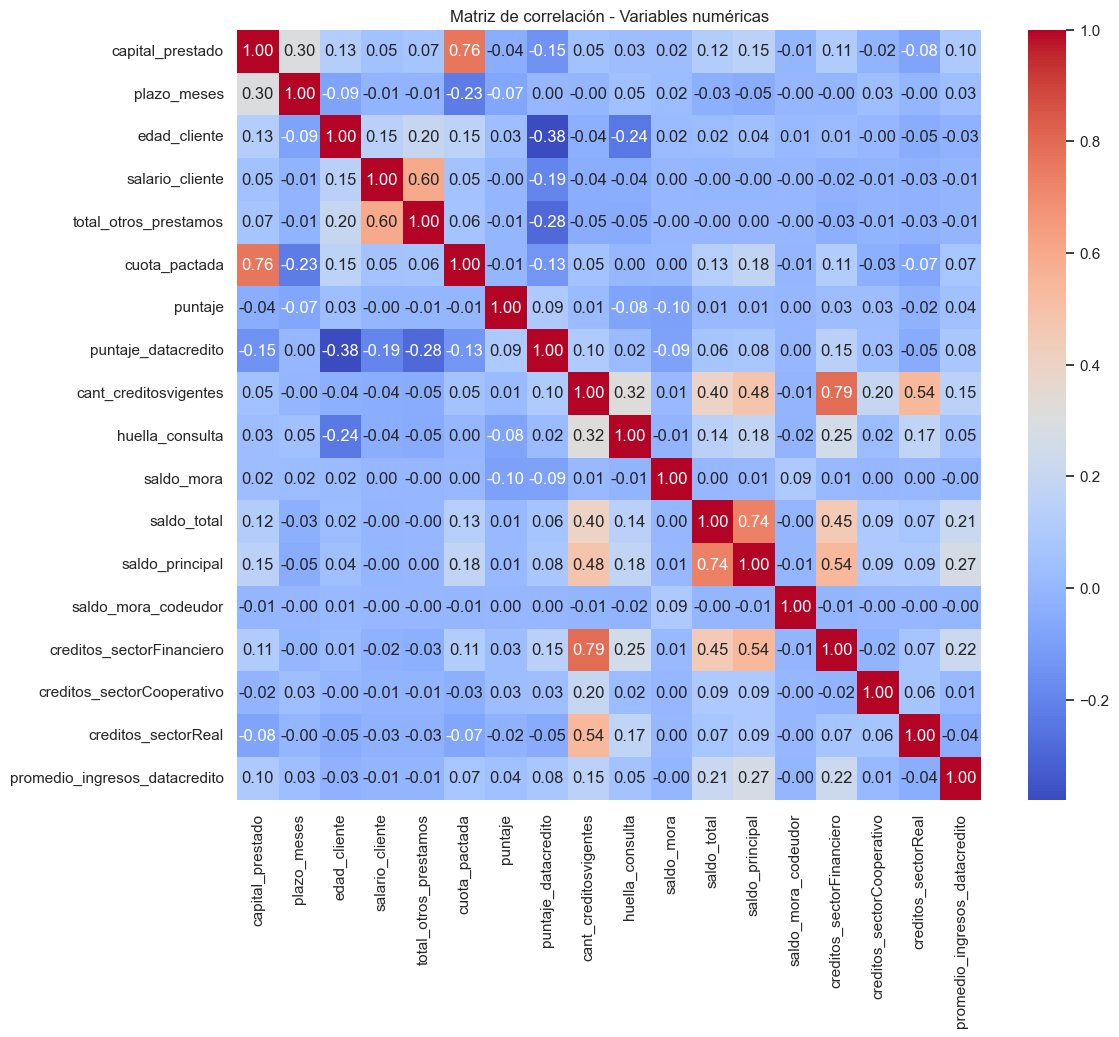

Interpretación: [ejemplo] Alta correlación entre salario_cliente y cuota_pactada → posible multicolinealidad.


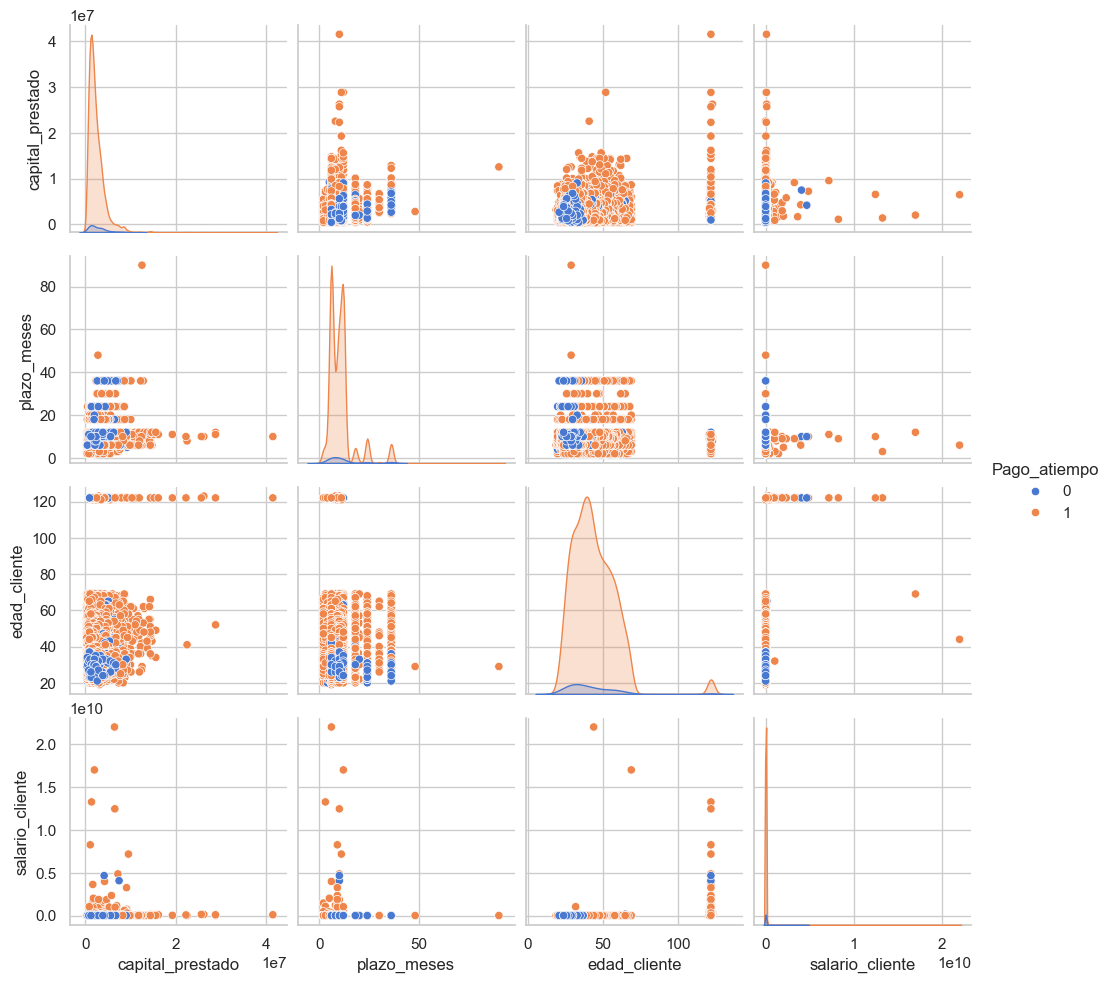

In [10]:
## 9. Análisis Multivariable
print("=== ANÁLISIS MULTIVARIABLE ===")

# Matriz de correlación (solo numéricas)
corr = df[numericas].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación - Variables numéricas')
plt.show()

print("Interpretación: [ejemplo] Alta correlación entre salario_cliente y cuota_pactada → posible multicolinealidad.")

# Pairplot (selecciona pocas para no sobrecargar)
sns.pairplot(df[numericas[:4] + ['Pago_atiempo']], hue='Pago_atiempo')
plt.show()

In [11]:
## 10. Insights y recomendaciones finales
print("=== INSIGHTS Y RECOMENDACIONES ===")

print("""
- tendencia_ingresos quedó limpia y ordinal: Decreciente < Estable < Creciente
- Alta presencia de 'Sin_dato' y 'Error_dato' → posible indicador de riesgo crediticio.
- Reglas de validación sugeridas:
  - edad_cliente > 18 y < 90
  - capital_prestado > 0
  - cuota_pactada ≤ salario_cliente * 0.5 (regla de esfuerzo financiero)
- Transformaciones posibles: log(1 + huella_consulta), bins para edad_cliente
- Atributos derivados sugeridos:
  - ratio_cuota_salario = cuota_pactada / salario_cliente
  - riesgo_huella = 1 si huella_consulta > 6 else 0
  - ingreso_por_credito = salario_cliente / cant_creditosvigentes
- Observación general: Dataset con posible desbalance en Pago_atiempo → considerar técnicas de balanceo en modelado.
""")

=== INSIGHTS Y RECOMENDACIONES ===

- tendencia_ingresos quedó limpia y ordinal: Decreciente < Estable < Creciente
- Alta presencia de 'Sin_dato' y 'Error_dato' → posible indicador de riesgo crediticio.
- Reglas de validación sugeridas:
  - edad_cliente > 18 y < 90
  - capital_prestado > 0
  - cuota_pactada ≤ salario_cliente * 0.5 (regla de esfuerzo financiero)
- Transformaciones posibles: log(1 + huella_consulta), bins para edad_cliente
- Atributos derivados sugeridos:
  - ratio_cuota_salario = cuota_pactada / salario_cliente
  - riesgo_huella = 1 si huella_consulta > 6 else 0
  - ingreso_por_credito = salario_cliente / cant_creditosvigentes
- Observación general: Dataset con posible desbalance en Pago_atiempo → considerar técnicas de balanceo en modelado.

